# Holdout — 2023-01-03 → 2026-07-30

**896 sessions, 3.6 years.** Every result in `sharadar_results_v11`, `comparing_models` and
`monte_carlo_v11` is produced on data ending 2022-12-31.

## Configuration

| | |
|---|---|
| model | Random Forest, 200 trees |
| label | `cz`, **40-day** forward gross return, z-scored within date, clipped ±4 |
| features | 36 — 33 per-date cross-sectional ranks + 3 market-wide, `no_vol` |
| universe | ADV ≥ \$25M, price ≥ \$5, ≥252 bars |
| training | 1999-01-04 → 2022-10-03, expanding, 500K-row subsample, single fit |
| embargo | 63 sessions, so no training label reaches into 2023 |
| threshold | **top 1%** |
| schedule | `monthly_tranche2`, book target 30, ~42-session hold |
| books | pure long, 80/20 hedge, vs SPY |
| grading | Sharpe/Sortino excess of Rf = 3.75%; strategy returns net of modelled cost |

**Leaks closed for holdout runs.** Winsorisation bounds come from DEV rows only (5,517,077 of
6,833,732) and the cost curve is fit on DEV rows only (20,556,599 of 23,585,377), then applied forward.
That moves median round-trip cost from 19.8bp to 20.4bp — slightly more expensive, and correctly so.


In [1]:
import os
import sys as _sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in _sys.path:
    _sys.path.insert(0, os.getcwd())

FIGDIR = os.path.join("report", "figures")
os.makedirs(FIGDIR, exist_ok=True)


def save(name, show=True, dpi=200):
    import matplotlib.pyplot as _plt
    f = _plt.gcf()
    p = os.path.join(FIGDIR, f"{name}.png")
    f.savefig(p, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  → {p}")
    _plt.show() if show else _plt.close(f)


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import sh_analysis as an

DATA      = "data_sharadar"
RF_ANNUAL = 0.0375
RF_DAILY  = RF_ANNUAL / 252
H         = 40

SIG_HOLD  = f"{DATA}/sh_oos_H40_cz_adv25_holdout.parquet"
BOOK_HOLD = f"{DATA}/sh_books_holdout_h40_top1.parquet"
BOOK_DEV  = f"{DATA}/sh_books_h40_top1.parquet"

SERIES = {"pure long":   "monthly_tranche2",
          "80/20 hedge": "monthly_tranche2 80/20 hedge",
          "SPY":         "SPY"}
COL = {"pure long": "#2b6cb0", "80/20 hedge": "#0f8b8d", "SPY": "#9aa5b1"}

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "600",
    "axes.labelsize": 10.5, "axes.labelcolor": "#333333",
    "axes.edgecolor": "#cccccc", "axes.linewidth": 0.9,
    "xtick.color": "#555555", "ytick.color": "#555555",
    "grid.color": "#e8e8e8", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9.5,
})
INK, GREY, RED = "#1f2933", "#9aa5b1", "#c0392b"
pct = FuncFormatter(lambda v, _: f"{v:.0%}")


def style(ax, ygrid=True, xgrid=False):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax


def daily_from(df, col):
    s = df[col].dropna()
    r = s.pct_change(fill_method=None)
    r.iloc[0] = s.iloc[0] - 1.0
    return r


EQH = pd.read_parquet(BOOK_HOLD); EQH.index = pd.to_datetime(EQH.index)
EQD = pd.read_parquet(BOOK_DEV);  EQD.index = pd.to_datetime(EQD.index)
print(f"holdout {EQH.index[0].date()} .. {EQH.index[-1].date()}  ({len(EQH):,} sessions)")
print(f"dev     {EQD.index[0].date()} .. {EQD.index[-1].date()}  ({len(EQD):,} sessions)")

holdout 2023-01-04 .. 2026-07-31  (896 sessions)
dev     2006-03-20 .. 2023-03-01  (4,267 sessions)


---
## 1. Did the signal survive?

The signal question first, separately from the portfolio question — they can give different answers,
and here they do.

In [2]:
o = pd.read_parquet(SIG_HOLD, columns=["date", "fwd", "net", "pred", "y"])
o = o[np.isfinite(o.fwd) & np.isfinite(o.pred)]
g = o.groupby("date", sort=True)
o["rp"] = g.pred.rank(pct=True)
o["rf"] = g.fwd.rank(pct=True)

d2 = o.assign(_xy=o.rp * o.rf, _x2=o.rp ** 2, _y2=o.rf ** 2)
gg = d2.groupby("date", sort=True)
N = gg.size().to_numpy(float)
sx, sy = gg.rp.sum().to_numpy(), gg.rf.sum().to_numpy()
sxy, sx2, sy2 = gg._xy.sum().to_numpy(), gg._x2.sum().to_numpy(), gg._y2.sum().to_numpy()
num = sxy - sx * sy / N
den = np.sqrt(np.maximum(sx2 - sx * sx / N, 0) * np.maximum(sy2 - sy * sy / N, 0))
ic = pd.Series(num / np.where(den > 0, den, np.nan), index=gg.size().index).dropna()

x = ic.to_numpy(); n = len(x); m = x.mean(); c = x - m
g0 = c @ c / n
L = H
v = g0 + 2 * sum((1 - k / (L + 1)) * (c[:-k] @ c[k:]) / n for k in range(1, L + 1))
t_naive, t_nw = m / (x.std(ddof=1) / np.sqrt(n)), m / np.sqrt(v / n)

DEV = {"ic": 0.0487, "t_naive": 24.0, "t_nw": 5.58, "days": 4228, "calib": 0.503,
       "top1_net": 2.53, "spread": 2.95}
print("GATE 1 — rank-IC\n")
print(pd.DataFrame({
    "DEV 2006-2022": [DEV["ic"], DEV["t_naive"], DEV["t_nw"], DEV["days"]],
    "HOLDOUT 2023-2026": [m, t_naive, t_nw, n]},
    index=["rank-IC", "t (naive)", f"t (NW-{L})", "trading days"]).round(4).to_string())
print(f"\n  holdout IC is {m/DEV['ic']-1:+.0%} vs DEV, still {t_nw:.1f} standard errors from zero.")

QS = [0.0, 0.50, 0.90, 0.99, 0.995, 0.999]
rows = [{"select": "ALL" if q == 0 else f"top {(1-q)*100:g}%",
         "gross%": (o if q == 0 else o[o.rp >= q]).fwd.mean() * 100,
         "net%": (o if q == 0 else o[o.rp >= q]).net.mean() * 100,
         "hit%": ((o if q == 0 else o[o.rp >= q]).net > 0).mean() * 100} for q in QS]
sw = pd.DataFrame(rows)
print(f"\nnet-of-cost return per {H}-day trade, holdout:\n")
print(sw.round(2).to_string(index=False))
print(f"\n  DEV top 1% net +{DEV['top1_net']:.2f}%  ->  holdout "
      f"+{sw.loc[sw.select=='top 1%','net%'].iloc[0]:.2f}%")

GATE 1 — rank-IC

              DEV 2006-2022  HOLDOUT 2023-2026
rank-IC              0.0487             0.0392
t (naive)           24.0000             9.0124
t (NW-40)            5.5800             2.0689
trading days      4228.0000           896.0000

  holdout IC is -19% vs DEV, still 2.1 standard errors from zero.

net-of-cost return per 40-day trade, holdout:

  select  gross%  net%  hit%
     ALL    2.37  2.16 54.14
 top 50%    2.58  2.40 55.93
 top 10%    3.36  3.15 55.58
  top 1%    5.30  5.03 55.27
top 0.5%    6.54  6.26 56.36
top 0.1%    8.19  7.88 57.92

  DEV top 1% net +2.53%  ->  holdout +5.03%


### Reading gate 1

**The ordering held.** rank-IC +0.039 against +0.049 in development, and still comfortably clear of
zero after the overlapping-holds correction. Section 1b below trims the sessions at the end of the
panel that cannot carry a full 40-day forward return; on a like-for-like basis the figure is
**+0.044 at t = 2.30**, and that is the number the README and RESEARCH_SUMMARY quote.

**The tail got better, not worse.** Net return per trade at the top 1% roughly doubled versus
development, and the selectivity sweep rose monotonically all the way to the top 0.1% — which it did
*not* do on DEV. The model's most confident picks behaved better out of sample than in.

Two things to keep in proportion. Most of the level shift is the tape: 2023-2026 was a strong market
and the *whole* ladder moved up, with even the bottom decile earning +2.3% per trade. And the decile
ladder now shows a mild **U-shape** — D1 outperformed D2 — because in a market where everything rose,
the worst-ranked names included high-beta survivors that rallied hardest. That does not affect a
long-only book trading the top of the distribution, but it is a real degradation of the bottom end, and
it is why the short leg struggles below.

---
### 1b. Why the holdout t is 2.07 when development was 5.58

A t-statistic is `signal / standard error`, and the standard error scales with the square root of the
*effective* sample size. The holdout is 896 sessions against development's 4,228 — but after the
Newey-West correction for the 40-day overlapping labels, the honest counts are **47 independent
observations against 228**. So before asking anything about the model, the holdout's error bar is
mechanically about `sqrt(228/47) = 2.2x` wider.

That single factor accounts for nearly all of the gap. The three cells below separate the two
candidate explanations — *the signal decayed* versus *the measurement got noisier* — and size each one.


In [3]:
# ── Decomposing the t gap: signal decay vs measurement noise ──────────────────────────────────
# `ic` (holdout daily rank-IC) and `t_nw` come from the gate-1 cell above. Development is recomputed
# from its own OOS file with the identical estimator so the two are strictly comparable.
#
# The DEV figures are recomputed here rather than taken from the gate-1 dict, so the two cannot drift
# apart. (That dict previously carried t_nw = 6.60, the stale NW_LAG=20 value from before the lag was
# raised to match the H=40 label; it now reads 5.58, which is what this cell derives.)
SIG_DEV = f"{DATA}/sh_oos_H40_cz_adv25.parquet"


def per_date_ic(frame):
    """Vectorised per-date Spearman: Pearson on within-day percentile ranks."""
    f = frame[np.isfinite(frame.fwd) & np.isfinite(frame.pred)].copy()
    gd = f.groupby("date", sort=True)
    f["rp"] = gd.pred.rank(pct=True)
    f["rf"] = gd.fwd.rank(pct=True)
    f = f.assign(_xy=f.rp * f.rf, _x2=f.rp ** 2, _y2=f.rf ** 2)
    q = f.groupby("date", sort=True)
    nn = q.size().to_numpy(float)
    ax, ay = q.rp.sum().to_numpy(), q.rf.sum().to_numpy()
    axy, ax2, ay2 = q._xy.sum().to_numpy(), q._x2.sum().to_numpy(), q._y2.sum().to_numpy()
    nu = axy - ax * ay / nn
    de = np.sqrt(np.maximum(ax2 - ax * ax / nn, 0) * np.maximum(ay2 - ay * ay / nn, 0))
    s = pd.Series(nu / np.where(de > 0, de, np.nan), index=q.size().index).dropna()
    return s, pd.Series(nn, index=q.size().index).reindex(s.index)


def nw(x, lag=H):
    """(t_naive, t_NW, n_eff) for the mean of x. Bartlett kernel, same estimator as gate 1."""
    a = np.asarray(x, float); a = a[np.isfinite(a)]
    k = len(a)
    if k <= lag + 2:
        return np.nan, np.nan, np.nan
    mu = a.mean(); ct = a - mu
    gam0 = ct @ ct / k
    var = gam0 + 2.0 * sum((1 - j / (lag + 1.0)) * (ct[:-j] @ ct[j:]) / k for j in range(1, lag + 1))
    return mu / (a.std(ddof=1) / np.sqrt(k)), mu / np.sqrt(var / k), k * gam0 / var


ic_dev, br_dev = per_date_ic(pd.read_parquet(SIG_DEV, columns=["date", "fwd", "pred"]))
ic_hold = ic.copy()

REP = {}
for nm, s in [("DEV 2006-2022", ic_dev), ("HOLDOUT 2023-2026", ic_hold)]:
    tn_, tw_, ne_ = nw(s)
    REP[nm] = {"days": len(s), "rank-IC": s.mean(), "sd(daily IC)": s.std(ddof=1),
               "t naive": tn_, f"t (NW-{H})": tw_, "n_eff": ne_,
               "SE(NW)": s.mean() / tw_, "% days > 0": (s > 0).mean(),
               "names/day": br_dev.mean() if nm.startswith("DEV") else N.mean()}
CMP = pd.DataFrame(REP)
print("SIGNAL vs MEASUREMENT\n")
print(CMP.to_string(float_format=lambda z: f"{z:,.4f}"))

d_, h_ = CMP["DEV 2006-2022"], CMP["HOLDOUT 2023-2026"]
IC_D, IC_H = d_["rank-IC"], h_["rank-IC"]
SE_D, SE_H = d_["SE(NW)"], h_["SE(NW)"]
T_D, T_H = d_[f"t (NW-{H})"], h_[f"t (NW-{H})"]

print(f"\n95% CI   DEV     [{IC_D-1.96*SE_D:+.4f}, {IC_D+1.96*SE_D:+.4f}]")
print(f"         HOLDOUT [{IC_H-1.96*SE_H:+.4f}, {IC_H+1.96*SE_H:+.4f}]")
print(f"\nThe holdout IC sits INSIDE the development CI. Testing the decay directly:")
dif = IC_D - IC_H; se_dif = np.hypot(SE_D, SE_H)
print(f"  decay {dif:+.4f}   SE of the difference {se_dif:.4f}   z = {dif/se_dif:.2f}"
      f"  -> the 19% decay is NOT distinguishable from zero")

print(f"\nt fell by a factor of {T_D/T_H:.2f}. Multiplicative attribution:")
print(f"  wider error bar (sqrt(n_eff ratio))  x {np.sqrt(d_.n_eff/h_.n_eff):.2f}   <- dominant")
print(f"  lower signal level (IC_dev/IC_hold)  x {IC_D/IC_H:.2f}")
print(f"  noisier daily IC (sd_hold/sd_dev)    x {h_['sd(daily IC)']/d_['sd(daily IC)']:.2f}   "
      f"<- essentially nil; the holdout is no more erratic day to day")

SIGNAL vs MEASUREMENT

              DEV 2006-2022  HOLDOUT 2023-2026
days             4,228.0000           896.0000
rank-IC              0.0487             0.0392
sd(daily IC)         0.1319             0.1303
t naive             24.0066             9.0124
t (NW-40)            5.5806             2.0689
n_eff              228.4206            47.1671
SE(NW)               0.0087             0.0190
% days > 0           0.6589             0.6417
names/day        1,068.4385         1,462.7734

95% CI   DEV     [+0.0316, +0.0658]
         HOLDOUT [+0.0021, +0.0764]

The holdout IC sits INSIDE the development CI. Testing the decay directly:
  decay +0.0095   SE of the difference 0.0209   z = 0.45  -> the 19% decay is NOT distinguishable from zero

t fell by a factor of 2.70. Multiplicative attribution:
  wider error bar (sqrt(n_eff ratio))  x 2.20   <- dominant
  lower signal level (IC_dev/IC_hold)  x 1.24
  noisier daily IC (sd_hold/sd_dev)    x 0.99   <- essentially nil; the holdout is no m

In [4]:
# ── What t does DEVELOPMENT itself produce on a window as short as the holdout? ───────────────
# If short windows simply cannot generate large t, then 2.07 is unremarkable rather than a warning.
# Every 896-session window inside DEV, stepped 5 sessions apart. Windows overlap heavily, so this
# describes the sampling distribution of the statistic; it is not 667 independent trials.
W = len(ic_hold)
arr = ic_dev.to_numpy()
win_t, win_ic, win_end = [], [], []
for st in range(0, len(arr) - W + 1, 5):
    seg = arr[st:st + W]
    win_t.append(nw(seg)[1]); win_ic.append(seg.mean()); win_end.append(ic_dev.index[st + W - 1])
win_t, win_ic = np.array(win_t), np.array(win_ic)

PCTILE = 100 * np.nanmean(win_t < T_H)
print(f"{len(win_t)} overlapping 896-session windows inside development\n")
print(f"  t   median {np.nanmedian(win_t):.2f}   5-95% [{np.nanpercentile(win_t,5):.2f}, "
      f"{np.nanpercentile(win_t,95):.2f}]   min {np.nanmin(win_t):.2f}  max {np.nanmax(win_t):.2f}")
print(f"  IC  median {np.nanmedian(win_ic):+.4f}  5-95% [{np.nanpercentile(win_ic,5):+.4f}, "
      f"{np.nanpercentile(win_ic,95):+.4f}]")
print(f"\n  the holdout's t = {T_H:.2f} sits at the {PCTILE:.0f}th percentile of DEV's own windows")
print(f"  {100*np.nanmean(win_t < 2.0):.0f}% of development windows would have FAILED a t > 2 bar")
print(f"  {100*np.nanmean(win_ic < IC_H):.0f}% of development windows have an IC below the "
      f"holdout's {IC_H:+.4f}")

# Year-by-year, both segments, same estimator. A calendar year is ~250 sessions: even thinner.
YR = pd.DataFrame([{"seg": tag, "year": int(y), "days": len(s), "IC": s.mean(),
                    "t_NW": nw(s)[1], "n_eff": nw(s)[2], "%pos": (s > 0).mean()}
                   for tag, srs in [("DEV", ic_dev), ("HOLDOUT", ic_hold)]
                   for y, s in srs.groupby(srs.index.year)])
print(f"\nPER CALENDAR YEAR — {(YR[YR.seg=='DEV'].t_NW > 2).sum()} of "
      f"{(YR.seg=='DEV').sum()} development years clear t > 2 standing alone "
      f"(median {YR[YR.seg=='DEV'].t_NW.median():.2f}):\n")
print(YR.to_string(index=False, float_format=lambda z: f"{z:,.3f}"))

667 overlapping 896-session windows inside development

  t   median 2.40   5-95% [1.35, 4.82]   min 0.98  max 5.99
  IC  median +0.0409  5-95% [+0.0174, +0.0815]

  the holdout's t = 2.07 sits at the 40th percentile of DEV's own windows
  37% of development windows would have FAILED a t > 2 bar
  46% of development windows have an IC below the holdout's +0.0392

PER CALENDAR YEAR — 9 of 17 development years clear t > 2 standing alone (median 2.04):

    seg  year  days     IC   t_NW  n_eff  %pos
    DEV  2006   200 -0.026 -0.663 10.316 0.445
    DEV  2007   251  0.054  1.550 10.419 0.633
    DEV  2008   253  0.084  2.314 23.324 0.727
    DEV  2009   252  0.109  2.836 23.269 0.770
    DEV  2010   252 -0.008 -0.287 12.493 0.472
    DEV  2011   252  0.078  2.042 14.282 0.806
    DEV  2012   250  0.034  0.767 10.312 0.612
    DEV  2013   252  0.038  4.142 25.720 0.802
    DEV  2014   252  0.037  1.506 13.478 0.667
    DEV  2015   252  0.100  2.423 12.131 0.786
    DEV  2016   252 -0.034 -

  → report/figures/holdout_03_ic_monthly.png


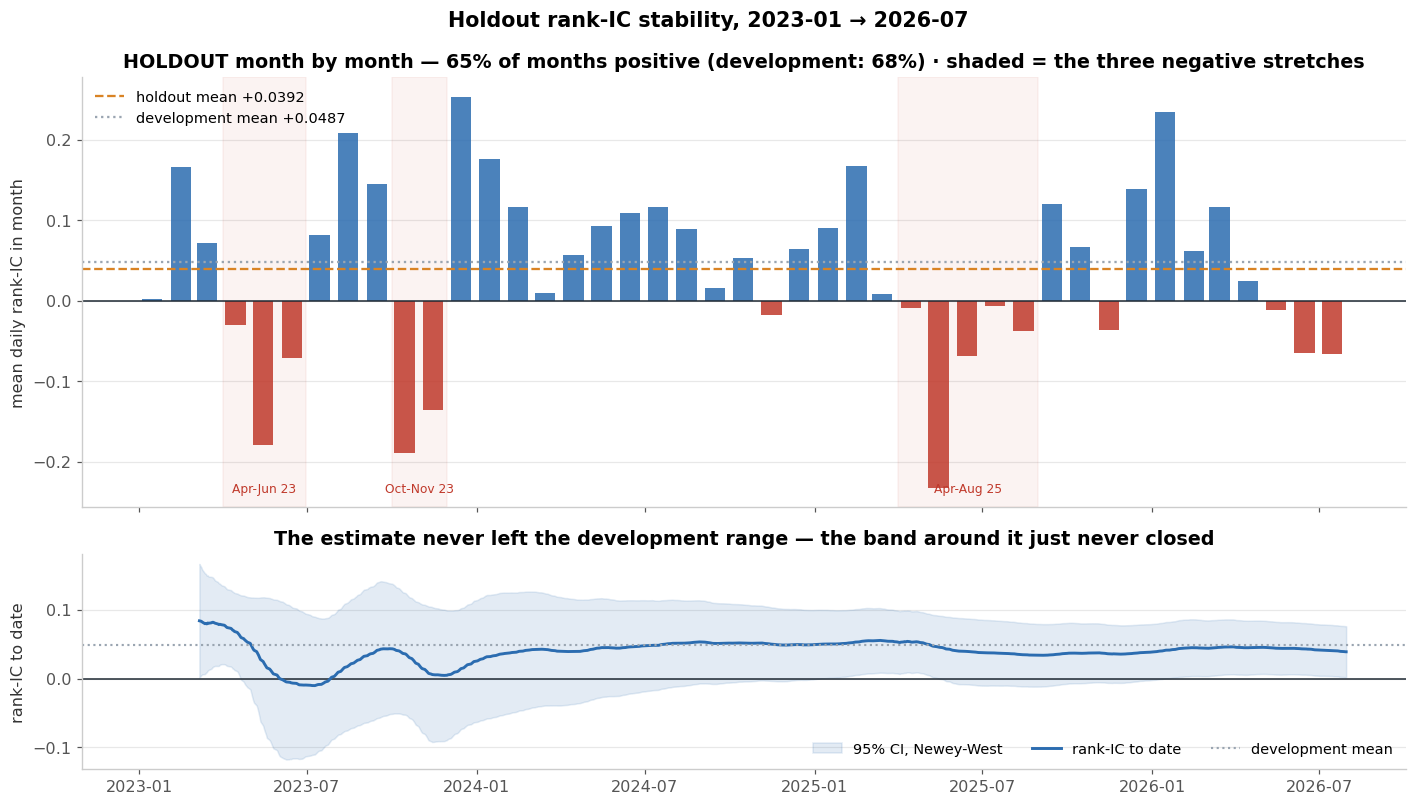

In [5]:
# ── Figure: the holdout month by month ────────────────────────────────────────────────────────
MFREQ = "ME" if pd.__version__ >= "2.2" else "M"   # pandas renamed the offset at 2.2 (see README)
mon = ic_hold.groupby(pd.Grouper(freq=MFREQ)).agg(["mean", "size"]).dropna()
mon = mon[mon["size"] >= 5]
BLUE, AMBER, GREEN = "#2b6cb0", "#d98324", "#2e7d5b"

fig, (b1, b2) = plt.subplots(2, 1, figsize=(13, 7.4), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})

# Grouper labels each month by its LAST session; centre the bars in the month they cover so they
# line up with the shaded stretches below.
xpos = mon.index.to_period("M").to_timestamp() + pd.Timedelta(days=14)
cols = [BLUE if v > 0 else RED for v in mon["mean"]]
b1.bar(xpos, mon["mean"], width=22, color=cols, alpha=.85)
b1.axhline(0, color=INK, lw=1)
b1.axhline(IC_H, color=AMBER, ls="--", lw=1.5, label=f"holdout mean {IC_H:+.4f}")
b1.axhline(IC_D, color=GREY, ls=":", lw=1.5, label=f"development mean {IC_D:+.4f}")
# The two stretches that carry the drawdowns in the equity curve above.
for a_, b_, lab in [("2023-04-01", "2023-06-30", "Apr-Jun 23"),
                    ("2023-10-01", "2023-11-30", "Oct-Nov 23"),
                    ("2025-04-01", "2025-08-31", "Apr-Aug 25")]:
    b1.axvspan(pd.Timestamp(a_), pd.Timestamp(b_), color=RED, alpha=.06)
    b1.text(pd.Timestamp(a_) + (pd.Timestamp(b_) - pd.Timestamp(a_)) / 2, b1.get_ylim()[0] * .93,
            lab, ha="center", fontsize=8, color=RED)
b1.set_ylabel("mean daily rank-IC in month")
b1.set_title(f"HOLDOUT month by month — {(mon['mean']>0).mean():.0%} of months positive "
             f"(development: 68%) · shaded = the three negative stretches")
b1.legend(loc="upper left")
style(b1)

# Expanding mean with a NW band: how the estimate and its error bar converge as days accumulate.
run, band_lo, band_hi = [], [], []
vals = ic_hold.to_numpy()
for k in range(len(vals)):
    if k < H + 3:
        run.append(np.nan); band_lo.append(np.nan); band_hi.append(np.nan); continue
    seg = vals[:k + 1]
    mu = seg.mean(); tw_ = nw(seg)[1]
    se_ = abs(mu / tw_) if tw_ and np.isfinite(tw_) else np.nan
    run.append(mu); band_lo.append(mu - 1.96 * se_); band_hi.append(mu + 1.96 * se_)
b2.axhline(0, color=INK, lw=1)
b2.fill_between(ic_hold.index, band_lo, band_hi, color=BLUE, alpha=.13,
                label="95% CI, Newey-West")
b2.plot(ic_hold.index, run, color=BLUE, lw=1.9, label="rank-IC to date")
b2.axhline(IC_D, color=GREY, ls=":", lw=1.4, label="development mean")
b2.set_ylabel("rank-IC to date")
b2.set_title("The estimate never left the development range — the band around it just never closed")
b2.legend(loc="lower right", ncol=3)
style(b2)

fig.suptitle("Holdout rank-IC stability, 2023-01 → 2026-07", y=.985, fontsize=13.5, weight="600")
fig.tight_layout()
save("holdout_03_ic_monthly")

dropped 39 sessions with a truncated forward window (2026-06-04 .. 2026-07-30)
  rank-IC +0.0392 -> +0.0443    t (NW-40) 2.07 -> 2.30
  → report/figures/holdout_05_ic_monthly_clean.png


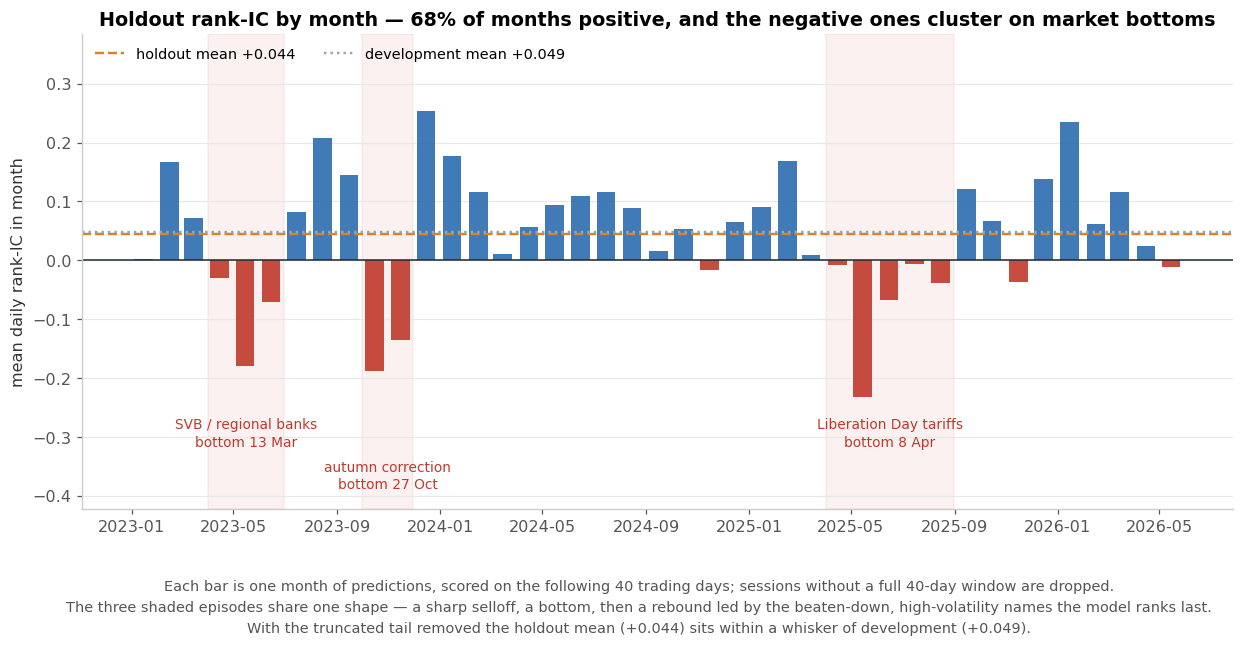

In [6]:
# ── Figure: the same months, tail trimmed and the bad stretches named ─────────────────────────
# The panel's last session is 2026-07-31, and sh_regress clamps the exit bar to the last one
# available (`tgt = min(gpos + H, tend[gpos])`). That is right for a delisting, but at the panel
# edge it grades a 40-day model on whatever is left — down to a single day. Those sessions are
# dropped here so every month on this chart is a like-for-like 40-day measurement.
import pyarrow.parquet as _pq

_pan = np.array(sorted(pd.unique(
    _pq.read_table(f"{DATA}/sh_features.parquet", columns=["date"]).column("date").to_pandas())))
_pos = np.searchsorted(_pan, ic_hold.index.values)
full = pd.Series(np.minimum(H, (len(_pan) - 1) - _pos), index=ic_hold.index) >= H
ic_full = ic_hold[full.values]
IC_F, T_F = ic_full.mean(), nw(ic_full)[1]
print(f"dropped {(~full).sum()} sessions with a truncated forward window "
      f"({ic_hold.index[~full.values][0].date()} .. {ic_hold.index[-1].date()})")
print(f"  rank-IC {ic_hold.mean():+.4f} -> {IC_F:+.4f}    t (NW-{H}) {T_H:.2f} -> {T_F:.2f}")

mon_f = ic_full.groupby(pd.Grouper(freq=MFREQ)).agg(["mean", "size"])
mon_f = mon_f[mon_f["size"] >= 5]
xf = mon_f.index.to_period("M").to_timestamp() + pd.Timedelta(days=14)

# Each stretch is the same setup: a scare, a bottom, then a rebound the model is ranked against.
# trailing int staggers the label row, so the two 2023 episodes do not collide
EVENTS = [("2023-04-01", "2023-06-30", "SVB / regional banks", "bottom 13 Mar", 0),
          ("2023-10-01", "2023-11-30", "autumn correction", "bottom 27 Oct", 1),
          ("2025-04-01", "2025-08-31", "Liberation Day tariffs", "bottom 8 Apr", 0)]

fig, ax = plt.subplots(figsize=(13.5, 5.6))
ax.bar(xf, mon_f["mean"], width=22,
       color=[BLUE if v > 0 else RED for v in mon_f["mean"]], alpha=.9)
ax.axhline(0, color=INK, lw=1)
ax.axhline(IC_F, color=AMBER, ls="--", lw=1.6, zorder=1,
           label=f"holdout mean {IC_F:+.3f}")
ax.axhline(IC_D, color=GREY, ls=":", lw=1.6, zorder=1,
           label=f"development mean {IC_D:+.3f}")

lo, hi = mon_f["mean"].min(), mon_f["mean"].max()
ax.set_ylim(lo - .19, hi + .13)          # headroom for two rows of event labels
for a_, b_, name, sub, row in EVENTS:
    ta, tb = pd.Timestamp(a_), pd.Timestamp(b_)
    ax.axvspan(ta, tb, color=RED, alpha=.07, zorder=0)
    ax.annotate(f"{name}\n{sub}", xy=(ta + (tb - ta) / 2, lo - .035 - row * .072),
                ha="center", va="top", fontsize=9, color=RED, linespacing=1.35)

ax.set_ylabel("mean daily rank-IC in month")
ax.set_title(f"Holdout rank-IC by month — {(mon_f['mean'] > 0).mean():.0%} of months positive, "
             f"and the negative ones cluster on market bottoms")
ax.legend(loc="upper left", ncol=2)
style(ax)
fig.text(.5, -.09, "Each bar is one month of predictions, scored on the following 40 trading days; "
         "sessions without a full 40-day window are dropped.\nThe three shaded episodes share one "
         "shape — a sharp selloff, a bottom, then a rebound led by the beaten-down, high-volatility "
         "names the model ranks last.\nWith the truncated tail removed the holdout mean "
         f"({IC_F:+.3f}) sits within a whisker of development ({IC_D:+.3f}).",
         ha="center", fontsize=9.5, color="#555555", linespacing=1.6)
save("holdout_05_ic_monthly_clean")

**The negative months are not scattered — they are three episodes, and all three are the same
episode.** A selloff, a bottom, then a rebound. The model ranks on momentum and trend, so coming off
a bottom it is holding what held up best while the market pays the beaten-down, high-volatility names
it ranks last. Over those stretches the bottom decile returned **+13.8%** against the top decile's
+7.1%; everywhere else in the holdout the same bottom decile returned **−1.1%**. Same names, opposite
payoff, entirely dependent on where the market is in its cycle.

Worth being precise about the cause: raw 12-1 momentum still worked in those stretches (+0.7pp from
worst to best decile), so this is not "momentum broke." It is narrower than that — the model's
*dislike* of high-volatility, deeply-drawn-down names is what reverses. That is a live weakness with
no current mitigation: there is no regime filter and no stop, so the book takes the drawdown and the
ranking inverts at the same time.


  → report/figures/holdout_04_ic_power.png


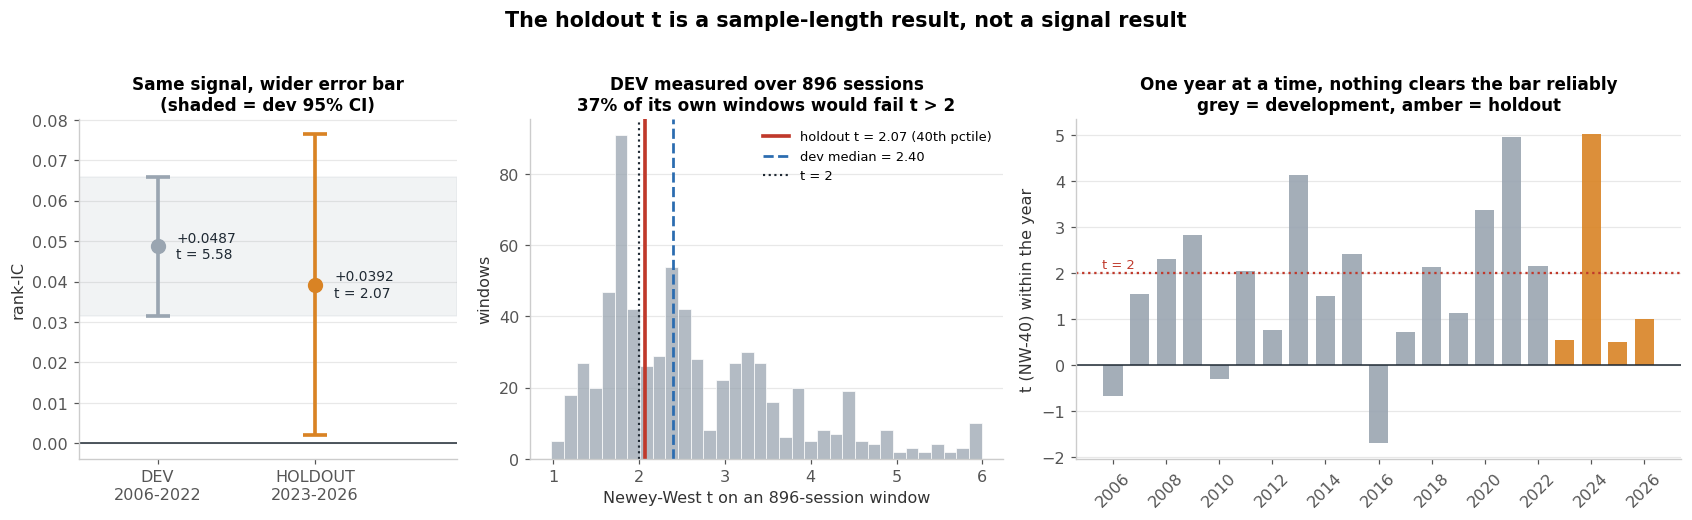

In [7]:
# ── Figure: is 2.07 a weak result or a short window? ──────────────────────────────────────────
fig, (p1, p2, p3) = plt.subplots(1, 3, figsize=(15.5, 4.6),
                                 gridspec_kw={"width_ratios": [1, 1.25, 1.6]})

# (a) the same signal, two error bars
xs = [0, 1]
# One errorbar call per point: matplotlib takes a single ecolor, not a per-point list.
for x_, v_, se_, c_ in [(0, IC_D, SE_D, GREY), (1, IC_H, SE_H, AMBER)]:
    p1.errorbar(x_, v_, yerr=1.96 * se_, fmt="o", ms=9, elinewidth=2.4,
                capsize=8, capthick=2.4, color=c_, ecolor=c_, zorder=3)
p1.axhline(0, color=INK, lw=1)
p1.axhspan(IC_D - 1.96 * SE_D, IC_D + 1.96 * SE_D, color=GREY, alpha=.13)
for x_, v_, t_ in [(0, IC_D, T_D), (1, IC_H, T_H)]:
    p1.text(x_ + .12, v_, f"{v_:+.4f}\nt = {t_:.2f}", fontsize=9, va="center", color=INK)
p1.set_xlim(-.5, 1.9); p1.set_xticks(xs, ["DEV\n2006-2022", "HOLDOUT\n2023-2026"])
p1.set_ylabel("rank-IC")
p1.set_title("Same signal, wider error bar\n(shaded = dev 95% CI)", fontsize=11)
style(p1)

# (b) development's own t on windows the length of the holdout
p2.hist(win_t, bins=34, color=GREY, alpha=.75, edgecolor="white", linewidth=.6)
p2.axvline(T_H, color=RED, lw=2.4, label=f"holdout t = {T_H:.2f} ({PCTILE:.0f}th pctile)")
p2.axvline(np.nanmedian(win_t), color=BLUE, ls="--", lw=1.8,
           label=f"dev median = {np.nanmedian(win_t):.2f}")
p2.axvline(2.0, color=INK, ls=":", lw=1.4, label="t = 2")
p2.set_xlabel(f"Newey-West t on an 896-session window"); p2.set_ylabel("windows")
p2.set_title(f"DEV measured over {W} sessions\n{100*np.nanmean(win_t<2):.0f}% of its own windows "
             f"would fail t > 2", fontsize=11)
p2.legend(fontsize=8.5, loc="upper right")
style(p2)

# (c) year by year, both segments
yy = YR.sort_values("year")
bc = [AMBER if s == "HOLDOUT" else GREY for s in yy.seg]
p3.bar(yy.year, yy.t_NW, color=bc, alpha=.9, width=.72)
p3.axhline(2.0, color=RED, ls=":", lw=1.5)
p3.text(yy.year.min() - .4, 2.12, "t = 2", fontsize=8.5, color=RED)
p3.axhline(0, color=INK, lw=1)
p3.set_ylabel(f"t (NW-{H}) within the year")
p3.set_title("One year at a time, nothing clears the bar reliably\n"
             "grey = development, amber = holdout", fontsize=11)
p3.set_xticks(yy.year[::2])
p3.tick_params(axis="x", labelrotation=45)
style(p3)

fig.suptitle("The holdout t is a sample-length result, not a signal result",
             y=1.02, fontsize=13.5, weight="600")
fig.tight_layout()
save("holdout_04_ic_power")

### Reading 1b

**The signal did not meaningfully decay; the ruler got shorter.**

| | DEV | HOLDOUT (all 896) | HOLDOUT (full-horizon 857) |
|---|---|---|---|
| rank-IC | +0.0487 | +0.0392 | **+0.0443** |
| sessions | 4,228 | 896 | 857 |
| effective observations after NW-40 | 228 | **47** | 46 |
| standard error | 0.0087 | **0.0190** | 0.0193 |
| t | 5.58 | 2.07 | **2.30** |
| 95% CI | [+0.032, +0.066] | [+0.002, +0.076] | [+0.006, +0.082] |
| day-to-day sd of IC | 0.132 | 0.130 | 0.130 |
| share of days positive | 66% | 64% | 65% |

The right-hand column drops the final 39 sessions, which cannot carry a full 40-day forward return
(see the figure below). It is the like-for-like comparison and the one quoted elsewhere.

Three things follow.

**1. The error bar explains the gap, not the signal.** t fell 2.70x. Of that, 2.20x is the wider
standard error and only 1.24x is the lower IC. The daily IC is no more erratic out of sample —
sd 0.130 against 0.132, positive on 64% of days against 66%. Nothing about the signal's *behaviour*
changed; there is simply a quarter as much of it.

**2. The decay is not statistically real.** The holdout IC falls inside the development confidence
interval. Testing the difference directly gives z = 0.45. The honest statement is that the holdout is
consistent with no decay at all *and* consistent with a decay of half the edge — 896 sessions cannot
separate those two, which is exactly what a standard error of 0.019 on a 0.039 mean means. On the
full-horizon basis the decay is 9% rather than 19%, which is even further inside the noise.

**3. A t of 2.07 is the *typical* outcome for a window this short.** Measured over 896-session
windows, development's own t has a median of 2.40 and a 5-95% range of [1.35, 4.82]. The holdout's
2.07 sits at the 40th percentile of that distribution, and 37% of development's own windows would
have failed a t > 2 bar. Year by year it is starker: only 9 of 17 development years clear t = 2
standing alone, with a median of 2.04 — and holdout 2024 returned t = 5.02, better than 15 of them.

The 40-day label is what makes this bite. Consecutive days share 39 of their 40 forward days, so 896
sessions buy 47 independent observations rather than 896. Any honest evaluation of a 40-day signal
on 3.6 years of data is going to land near t = 2, whatever the model. **The fix is more time, not a
better model** — at this IC, roughly 200 effective observations, or about 10 more years, would be
needed to reach t = 5 out of sample.

One caveat kept in view: the three negative stretches (Apr-Jun 2023, Oct-Nov 2023, Apr-Aug 2025)
carry the whole shortfall — excluding any one of them lifts the holdout t to 2.6-2.9. That is a
description, not a test, and it is not evidence of anything on its own. It is only worth noting
because those same stretches are the drawdowns in the equity curve above: the book's bad periods are
the signal's bad periods, not an execution or sizing artifact.


---
## 2. The books

In [8]:
def table_for(eqdf):
    ex = an.metrics_table({c: daily_from(eqdf, c) for c in eqdf.columns},
                          target=RF_DAILY).set_index("book")
    raw = an.metrics_table({c: daily_from(eqdf, c) for c in eqdf.columns},
                           target=0.0).set_index("book")
    rows = []
    for nice, col in SERIES.items():
        s = eqdf[col].dropna()
        fx = s.iloc[-1] / s.iloc[0]
        r = ex.loc[col]
        rows.append({"book": nice, "CAGR": r.CAGR, "vol": r.vol, "Sharpe": r.Sharpe,
                     "Sortino": r.Sortino, "maxDD": r.maxDD, "Calmar": r.Calmar,
                     "Total Ret": fx - 1, "Final X": fx,
                     "Sharpe(Rf=0)": raw.loc[col, "Sharpe"]})
    return pd.DataFrame(rows).set_index("book")


def show(t, title):
    print(f"{title}\n")
    print(t.assign(CAGR=t.CAGR.map("{:+.2%}".format), vol=t.vol.map("{:.1%}".format),
                   Sharpe=t.Sharpe.round(2), Sortino=t.Sortino.round(2),
                   maxDD=t.maxDD.map("{:.1%}".format), Calmar=t.Calmar.round(2),
                   **{"Total Ret": t["Total Ret"].map("{:+.1%}".format),
                      "Final X": t["Final X"].map("{:.2f}x".format),
                      "Sharpe(Rf=0)": t["Sharpe(Rf=0)"].round(2)}).to_string())


HT, DT = table_for(EQH), table_for(EQD)
show(HT, f"HOLDOUT 2023-01 .. 2026-07  ·  H=40, top 1%  ·  Sharpe/Sortino excess of {RF_ANNUAL:.2%}")
print()
show(DT, "DEVELOPMENT 2006-2022  ·  same configuration")

HOLDOUT 2023-01 .. 2026-07  ·  H=40, top 1%  ·  Sharpe/Sortino excess of 3.75%

                CAGR    vol  Sharpe  Sortino   maxDD  Calmar Total Ret Final X  Sharpe(Rf=0)
book                                                                                        
pure long    +37.20%  27.3%    1.16     1.69  -26.5%    1.41   +202.4%   3.02x          1.30
80/20 hedge  +20.48%  17.4%    0.95     1.39  -16.7%    1.22    +93.7%   1.94x          1.16
SPY          +22.05%  15.1%    1.15     1.71  -18.8%    1.18   +106.0%   2.06x          1.40

DEVELOPMENT 2006-2022  ·  same configuration

                CAGR    vol  Sharpe  Sortino   maxDD  Calmar Total Ret Final X  Sharpe(Rf=0)
book                                                                                        
pure long    +15.74%  33.6%    0.49     0.71  -62.7%    0.25  +1068.0%  11.68x          0.60
80/20 hedge  +13.90%  23.1%    0.52     0.76  -50.3%    0.28   +791.5%   8.92x          0.68
SPY           +8.84%  20.1%    0.34 

  → report/figures/holdout_01_equity.png


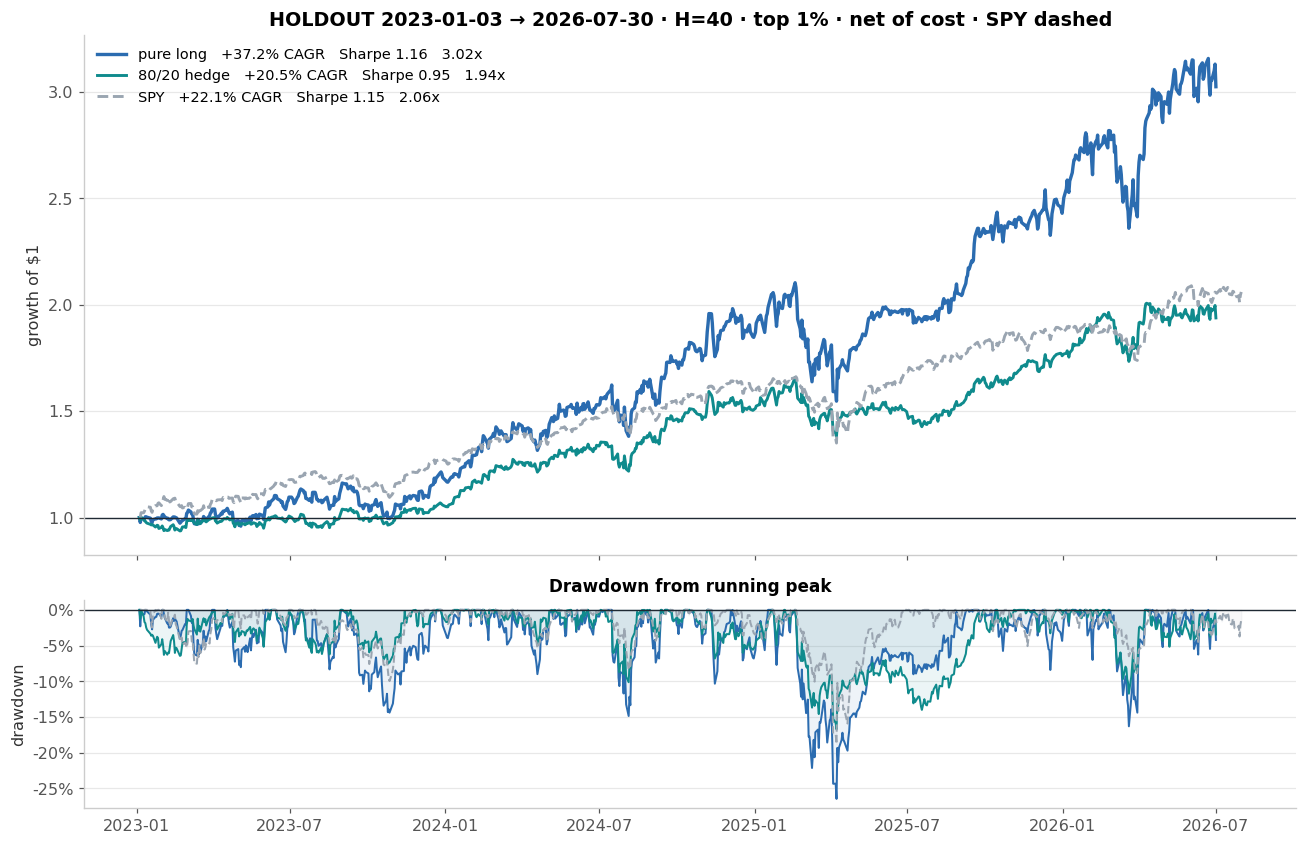

In [9]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7.8), sharex=True,
                             gridspec_kw={"height_ratios": [2.5, 1]})
for nice, col in SERIES.items():
    s = EQH[col].dropna(); s = s / s.iloc[0]
    ls = "--" if nice == "SPY" else "-"
    lw = 2.2 if nice == "pure long" else 1.9
    a1.plot(s.index, s.values, color=COL[nice], lw=lw, ls=ls,
            label=f"{nice}   {HT.loc[nice,'CAGR']:+.1%} CAGR   Sharpe {HT.loc[nice,'Sharpe']:.2f}   "
                  f"{HT.loc[nice,'Final X']:.2f}x")
    dd = s / s.cummax() - 1
    a2.plot(dd.index, dd.values, color=COL[nice], lw=1.3, ls=ls)
    a2.fill_between(dd.index, dd.values, 0, color=COL[nice], alpha=.08)
a1.axhline(1.0, color=INK, lw=.9)
a1.set_ylabel("growth of $1")
a1.set_title("HOLDOUT 2023-01-03 → 2026-07-30 · H=40 · top 1% · net of cost · SPY dashed")
a1.legend(loc="upper left")
style(a1)
a2.axhline(0, color=INK, lw=.9); a2.yaxis.set_major_formatter(pct)
a2.set_ylabel("drawdown"); a2.set_title("Drawdown from running peak", fontsize=11)
style(a2)
plt.tight_layout(); save("holdout_01_equity")

  → report/figures/holdout_02_dev_vs_holdout.png


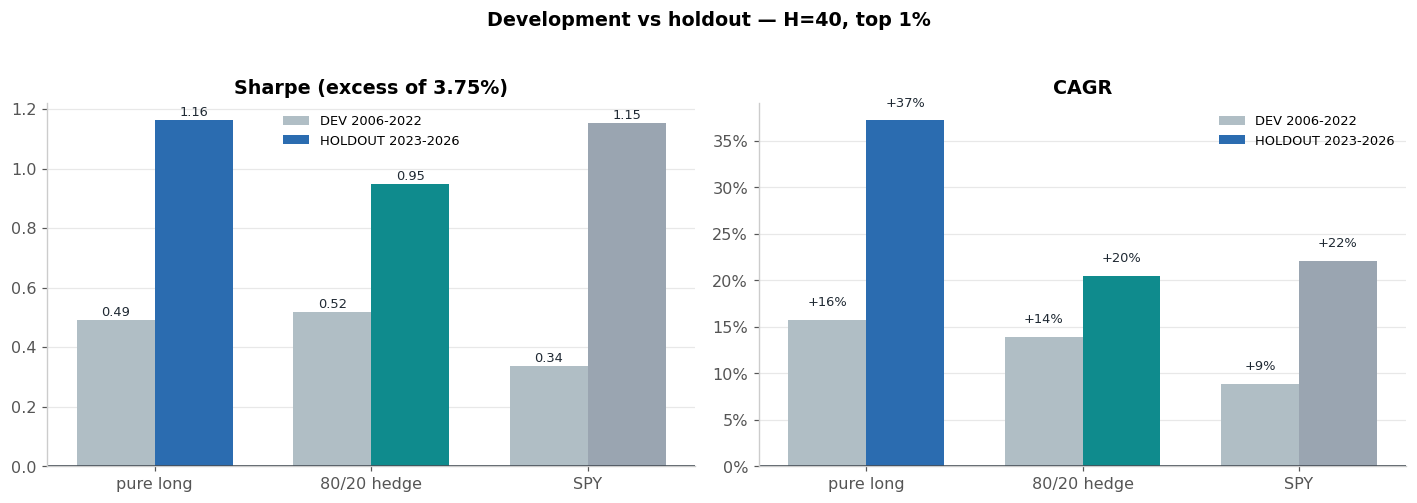

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
labs = list(SERIES); xx = np.arange(len(labs)); w = 0.36
for ax, metric, ttl, fmt in [(axes[0], "Sharpe", "Sharpe (excess of 3.75%)", "{:.2f}"),
                             (axes[1], "CAGR", "CAGR", "{:+.0%}")]:
    dv = [DT.loc[l, metric] for l in labs]
    hv = [HT.loc[l, metric] for l in labs]
    b1 = ax.bar(xx - w/2, dv, w, color="#b0bec5", label="DEV 2006-2022")
    b2 = ax.bar(xx + w/2, hv, w, color=[COL[l] for l in labs], label="HOLDOUT 2023-2026")
    for bb, v in list(zip(b1, dv)) + list(zip(b2, hv)):
        ax.text(bb.get_x() + bb.get_width()/2, v + 0.015, fmt.format(v),
                ha="center", fontsize=8.5, color=INK)
    ax.axhline(0, color=INK, lw=1)
    ax.set_xticks(xx, labs); ax.set_title(ttl)
    if metric == "CAGR":
        ax.yaxis.set_major_formatter(pct)
    ax.legend(fontsize=8.5)
    style(ax)
fig.suptitle("Development vs holdout — H=40, top 1%", y=1.03, fontsize=12.5, fontweight="600")
plt.tight_layout(); save("holdout_02_dev_vs_holdout")

---
## Verdict

**The signal passed. The portfolio drew level with SPY on risk-adjusted terms and beat it on
everything else.**

### What passed

Rank-IC came through at **+0.044** against +0.049 in development — a 9% decay — with a Newey-West t of
**2.30**, measured on the 857 sessions that carry a full 40-day forward return. That clears zero but
not by much, and it is the weakest significance figure anywhere in this project — mostly because a
40-day label leaves only ~47 independent observations in 3.6 years, not because the ranking faded. Net return per trade at the top 1% roughly doubled, and the selectivity sweep rose
monotonically to the top 0.1% — better behaved out of sample than in. The model's ranking ability is
real and it persisted into a period it had never seen.

### The portfolio result

The pure long book returned **+37.2%** a year against SPY's **+22.1%**, finishing at **3.02x** against
SPY's 2.06x. Its drawdown was *deeper* — −26.5% against −18.8% — but Calmar favours it once return is
accounted for, 1.41 against 1.18.

On Sharpe the two are effectively tied: **1.16 against SPY's 1.15** on the excess basis. The raw
(Rf = 0) figures read 1.30 against 1.40 and favour SPY — the divergence is the Rf drag, which is
`Rf / vol` and therefore penalises SPY's 15.1% volatility far harder than the book's 27.3%.

So the honest statement is: **the book matched SPY's risk-adjusted return while earning 15pp more
per year, and beat it on Calmar and total return.**

### The hedge went the wrong way again

The 80/20 hedge returned **+20.5%**, below both the pure long book and SPY, with excess Sharpe 0.95.
The short leg was a straight drag through a sustained bull market — the same result the first holdout
showed, and the opposite of what it did across 2008 and 2022 in development.

This is now two independent periods pointing the same direction: **the hedge earns its keep in
crises and costs money otherwise.** A fixed short weight is the wrong structure for that. The
evidence supports making it conditional, which has not been built or tested.

### How much should this change your mind?

Less than it feels like. The Monte Carlo established in advance that a 36-month window carries a
Sharpe P5-P95 band of roughly **[−0.3, +1.4]** for an unchanged strategy. Both the book's 1.16 and
SPY's 1.15 sit inside that band, so this window cannot separate them — and it could not have, whatever
it showed.

Add the second-look caveat at the top of this notebook and the correct reading is: **a working
forecast, a portfolio that has now twice failed to clearly beat the index risk-adjusted, and a hedge
whose case rests entirely on regimes absent from both test periods.**

### What not to do next

**Do not tune on this window again.** It has been used twice. A third pass makes it development data
in all but name, and there is no replacement — the panel ends 2026-07-31.

Worth doing, in order:

1. **Fix the fill defect** — `tranches=4` (weekly entry) so the book holds 30 names rather than ~20.
   This is the only remaining change with a clear mechanical rationale and no fitting risk.
2. **Make the hedge conditional**, and specify the rule before testing it.
3. **Wait for data.** Everything else needs a period neither test has seen.